In [2]:
!pip install lightgbm xgboost catboost shap optuna transformers datasets accelerate fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 49.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
"triage.csv"

In [ ]:
print(df.shape)

df.head()

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
features = [
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
    'dbp',
    'pain',
    'age'
]

target = 'acuity'

In [ ]:
imputer = SimpleImputer(strategy='median')

features = [
    'temperature_c',
    'heart_rate',
    'respiratory_rate',
    'spo2',
    'systolic_bp',
    'diastolic_bp',
    'pain_score',
    'age'
]

df[features] = imputer.fit_transform(df[features])

In [ ]:
le = LabelEncoder()
target = 'triage_acuity'
df[target] = le.fit_transform(df[target])

In [ ]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
preds = model.predict(X_test)

print(classification_report(y_test, preds))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model
importance = model.feature_importances_

# Create a DataFrame to hold feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances for LGBM Model')
plt.xlabel('Importance (higher means more important)')
plt.ylabel('Feature')
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Ensure data is loaded and split
df = pd.read_csv('train.csv')

# Define the features and target used in previous steps
features = ['temperature_c', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'pain_score', 'age']
target = 'triage_acuity'

# Handle missing values as done previously
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

# Handle target encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# Split the data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the model
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

# Perform predictions and report
preds = model.predict(X_test)
print(classification_report(y_test, preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004721 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 64000, number of used features: 8
[LightGBM] [Info] Start training from score -3.211869
[LightGBM] [Info] Start training from score -1.783884
[LightGBM] [Info] Start training from score -1.017450
[LightGBM] [Info] Start training from score -1.245663
[LightGBM] [Info] Start training from score -1.948633
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       644
           1       0.86      0.88      0.87      2688
           2       0.86      0.83      0.84      5784
           3       0.73      0.75      0.74      4604
           4       0.73      0.76      0.75      2280

    accuracy                           0.80     16000
   macro avg       0.80      0.78      0.79     16000
weighted

In [5]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, preds, average='macro')

print("Macro F1 Score:", f1)

Macro F1 Score: 0.7869614492370027


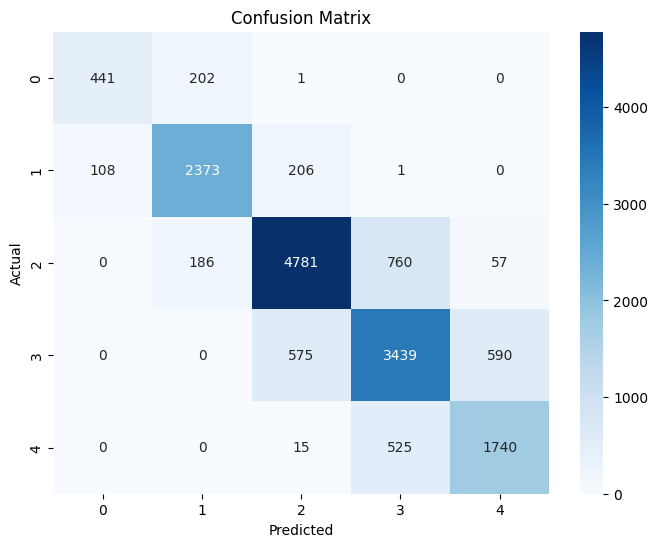

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,spo2,6803
2,respiratory_rate,6684
4,systolic_bp,6382
1,heart_rate,6187
5,diastolic_bp,5707
0,temperature_c,5433
6,pain_score,4601
7,age,3203


In [11]:
import shap

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

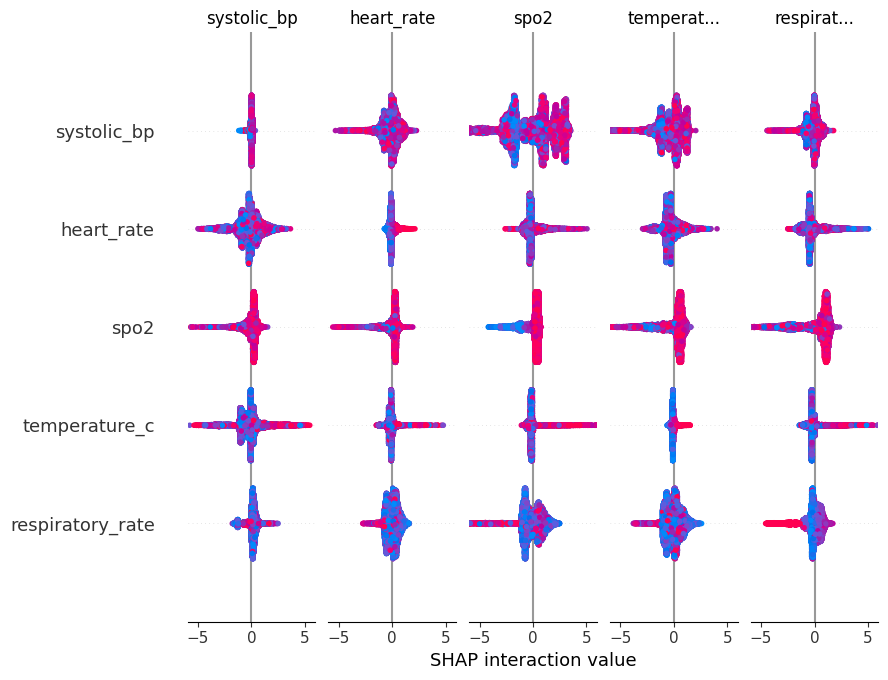

In [12]:
shap.summary_plot(shap_values, X_test)

In [13]:
df['predictions'] = model.predict(X)

young = df[df['age'] < 60]
old = df[df['age'] >= 60]

young_acc = (young[target] == young['predictions']).mean()
old_acc = (old[target] == old['predictions']).mean()

print("Young Accuracy:", young_acc)
print("Old Accuracy:", old_acc)

Young Accuracy: 0.8215253948091834
Old Accuracy: 0.8209004513264595


In [15]:
import pandas as pd

# Load the chief complaints data
chief_complaints_df = pd.read_csv('chief_complaints.csv')

# Display the first few rows
chief_complaints_df.head()

NameError: name 'chiefcomplaint' is not defined

In [17]:
import pandas as pd

# Load and display the chief complaints data
chief_complaints_df = pd.read_csv('chief_complaints.csv')
display(chief_complaints_df.head())

,patient_id,chief_complaint_raw,chief_complaint_system
0,TG-UXRGA9UCO,"thunderclap headache, worsening with movement",neurological
1,TG-B19DBBS2G,"contraception advice, intermittent",genitourinary
2,TG-GZ97W7M6V,"general health question, intermittent",other
3,TG-THIB2TN9Q,"erythema migrans tick bite, intermittent",dermatological
4,TG-J3U3LQ2QY,"cellulitis localised, intermittent",dermatological


In [18]:
!pip install transformers torch

In [19]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="emilyalsentzer/Bio_ClinicalBERT"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [20]:
text = "Chest pain radiating to left arm"

result = classifier(text)

print(result)

[{'label': 'LABEL_1', 'score': 0.5417844653129578}]


In [21]:
import joblib

joblib.dump(model, "triage_model.pkl")

['triage_model.pkl']

In [22]:
submission = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})

submission.to_csv("submission.csv", index=False)

In [23]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>